# Chapter 2 — Data and Sampling Distributions

**Practical Statistics for Data Scientists, 2nd Edition**  
Peter Bruce, Andrew Bruce, Peter Gedeck

Notebook ini mengikuti struktur contoh Bab 2 yang digunakan sebagai acuan, dengan kode ditulis agar dapat langsung dijalankan di Google Colab.

## Fokus Bab
- Random sampling dan sample bias
- Selection bias
- Regression to the mean
- Sampling distribution
- Central Limit Theorem (CLT)
- Standard error
- Bootstrap
- Confidence interval
- Normal distribution dan QQ-plot
- Long-tailed distributions
- Student's t-distribution
- Binomial distribution
- Chi-square distribution
- F-distribution
- Poisson, exponential, dan Weibull distributions

> Dataset utama mengikuti contoh buku dan diambil dari repository data pendamping buku.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.precision", 3)

BASE_URL = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"

loans_income = pd.read_csv(
    BASE_URL + "loans_income.csv"
).squeeze("columns")

loans_income.head()


,x
0,67000
1,52000
2,100000
3,78762
4,37041


## 1. Random Sampling and Sample Bias

**Population** adalah keseluruhan kelompok yang menjadi perhatian analisis, sedangkan **sample** adalah sebagian anggota population yang benar-benar diamati.

**Random sampling** memilih observasi secara acak sehingga sample diharapkan dapat mewakili population.

Hal penting dari bagian ini adalah membedakan:
- **sample size** → jumlah observasi;
- **sample quality** → seberapa baik sample mewakili population;
- **bias** → kesalahan sistematis akibat proses pengumpulan atau pemilihan data.

Ukuran data yang besar tidak otomatis menghilangkan bias. Jika proses pengambilan data sudah tidak representatif, sample yang besar tetap dapat menghasilkan kesimpulan yang bias.


In [ ]:
# Contoh random sampling dari data income
sample_income = loans_income.sample(n=1000, random_state=42)

summary_sampling = pd.Series({
    "Population size": len(loans_income),
    "Sample size": len(sample_income),
    "Population mean": loans_income.mean(),
    "Sample mean": sample_income.mean()
})

summary_sampling


,0
Population size,50000.000
Sample size,1000.000
Population mean,68760.518
Sample mean,66536.473


In [ ]:
population_mean = loans_income.mean()
sample_mean = sample_income.mean()

print(f"Population mean : {population_mean:,.2f}")
print(f"Sample mean     : {sample_mean:,.2f}")


Population mean : 68,760.52
Sample mean     : 66,536.47


### Interpretasi

Population mean dihitung dari seluruh data `loans_income`, sedangkan sample mean hanya menggunakan 1.000 observasi acak.

Perbedaan kedua nilai tersebut merupakan contoh bahwa statistik sample dapat berbeda dari parameter population karena adanya variasi sampling.


## 2. Selection Bias

**Selection bias** terjadi ketika cara memilih data menyebabkan sample berbeda secara sistematis dari population yang ingin dipelajari.

Bab ini juga membahas **data snooping**, yaitu mencari pola pada data berulang kali sampai menemukan hasil yang terlihat menarik. Semakin banyak pola yang dicari, semakin besar kemungkinan menemukan pola yang muncul hanya karena kebetulan.

Karena itu, analisis statistik perlu memperhatikan bagaimana data dikumpulkan dan dipilih, bukan hanya melihat hasil akhirnya.


## 3. Regression to the Mean

**Regression to the mean** adalah kecenderungan suatu pengukuran yang sangat ekstrem untuk diikuti pengukuran berikutnya yang lebih dekat dengan nilai rata-rata.

Hal ini tidak selalu berarti objek tersebut benar-benar mengalami perubahan. Variasi acak pada pengukuran pertama dapat membuat nilai terlihat sangat tinggi atau rendah.


In [ ]:
# Simulasi sederhana regression to the mean
rng = np.random.default_rng(42)

true_score = 70
first_measurement = true_score + rng.normal(0, 15, 1000)
second_measurement = true_score + rng.normal(0, 15, 1000)

extreme = first_measurement > np.quantile(first_measurement, 0.95)

print(
    "Rata-rata pengukuran pertama (5% tertinggi):",
    first_measurement[extreme].mean()
)
print(
    "Rata-rata pengukuran kedua untuk kelompok yang sama:",
    second_measurement[extreme].mean()
)
print("Rata-rata populasi simulasi:", true_score)


Rata-rata pengukuran pertama (5% tertinggi): 100.06254210387344
Rata-rata pengukuran kedua untuk kelompok yang sama: 67.87586195281071
Rata-rata populasi simulasi: 70


### Interpretasi

Kelompok yang dipilih karena memperoleh hasil sangat tinggi pada pengukuran pertama cenderung mempunyai nilai yang lebih dekat ke rata-rata pada pengukuran kedua. Ini merupakan ilustrasi regression to the mean.


## 4. Sampling Distribution of a Statistic

**Sampling distribution** adalah distribusi suatu statistik, misalnya mean, yang diperoleh ketika banyak sample diambil dari population yang sama dan statistik tersebut dihitung berulang kali.

Perbedaannya:
- **data distribution** → distribusi nilai individual dalam data;
- **sampling distribution** → distribusi statistik yang diperoleh dari banyak sample.

### Central Limit Theorem

**Central Limit Theorem (CLT)** menyatakan bahwa sampling distribution dari mean cenderung mendekati distribusi normal ketika ukuran sample cukup besar, walaupun data asalnya tidak harus normal.

Semakin besar ukuran sample, sampling distribution mean biasanya menjadi lebih sempit.


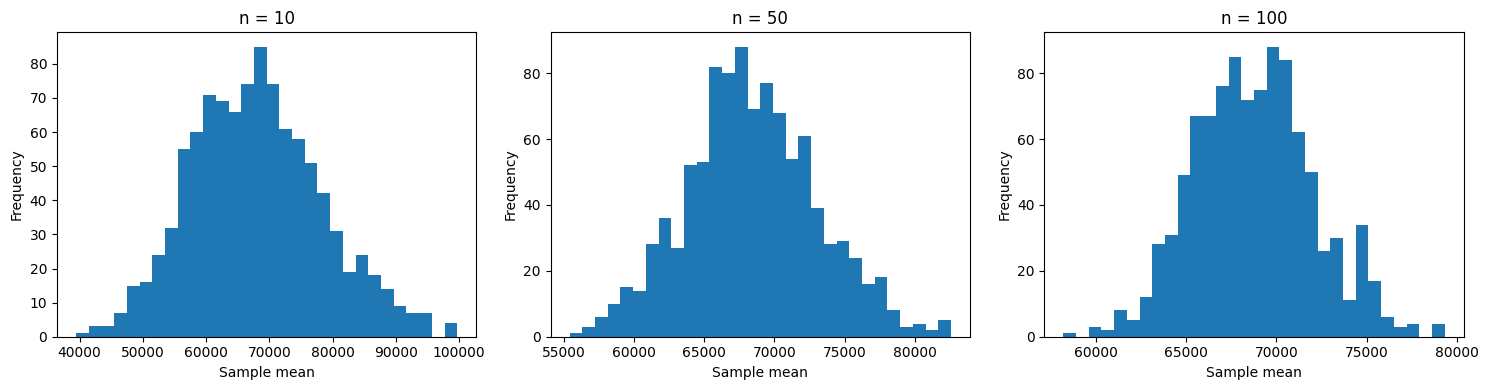

In [ ]:
# Membandingkan sampling distribution mean untuk beberapa ukuran sample
rng = np.random.default_rng(42)

sample_sizes = [10, 50, 100]
n_samples = 1000

means = {}

for n in sample_sizes:
    means[n] = np.array([
        rng.choice(loans_income, size=n, replace=True).mean()
        for _ in range(n_samples)
    ])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n in zip(axes, sample_sizes):
    ax.hist(means[n], bins=30)
    ax.set_title(f"n = {n}")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [ ]:
print("Standard deviation sampling distribution:")
for n in sample_sizes:
    print(f"n={n:<3}: {means[n].std(ddof=1):,.2f}")


### Interpretasi CLT

Ketika ukuran sample meningkat, penyebaran sample mean menjadi lebih kecil. Hal ini menunjukkan bahwa estimasi mean menjadi lebih stabil ketika ukuran sample diperbesar.


## 5. Standard Error

**Standard error (SE)** mengukur variabilitas suatu sample statistic, bukan variabilitas setiap observasi individual.

Untuk sample mean, bentuk umum yang digunakan adalah:

**SE ≈ s / √n**

dengan:
- `s` = standard deviation sample;
- `n` = ukuran sample.

Jadi, semakin besar `n`, standard error cenderung semakin kecil.


In [ ]:
sample_sd = sample_income.std()
n = len(sample_income)

se_mean = sample_sd / np.sqrt(n)

print(f"Sample standard deviation : {sample_sd:,.2f}")
print(f"Sample size               : {n}")
print(f"Standard error of mean    : {se_mean:,.2f}")


Sample standard deviation : 31,383.51
Sample size               : 1000
Standard error of mean    : 992.43


## 6. Bootstrap

**Bootstrap** adalah metode resampling dengan mengambil sample dari data yang tersedia secara berulang, biasanya dengan replacement.

Bootstrap berguna untuk memperkirakan variabilitas suatu statistik tanpa harus mengetahui bentuk distribusi population secara langsung.

Langkah sederhana:
1. ambil sample dari data asli dengan replacement;
2. hitung statistik;
3. ulangi berkali-kali;
4. lihat distribusi statistik yang dihasilkan.


In [ ]:
# Bootstrap distribution untuk mean
rng = np.random.default_rng(42)

bootstrap_means = np.array([
    rng.choice(sample_income, size=len(sample_income), replace=True).mean()
    for _ in range(2000)
])

print(f"Mean bootstrap : {bootstrap_means.mean():,.2f}")
print(f"Std bootstrap  : {bootstrap_means.std(ddof=1):,.2f}")


Mean bootstrap : 66,605.84
Std bootstrap  : 999.67


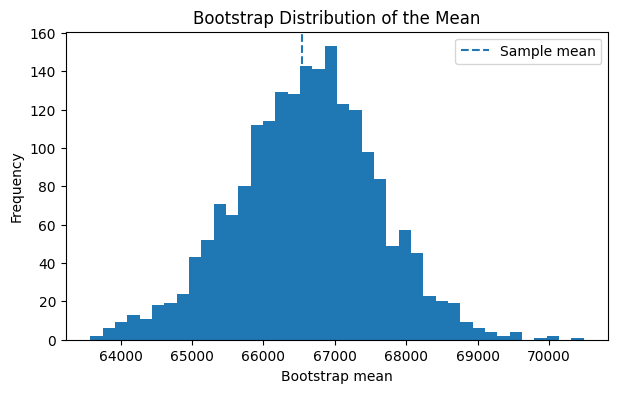

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(bootstrap_means, bins=40)
plt.axvline(sample_income.mean(), linestyle="--", label="Sample mean")
plt.xlabel("Bootstrap mean")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of the Mean")
plt.legend()
plt.show()


## 7. Confidence Interval dengan Bootstrap

Confidence interval memberikan rentang nilai yang digunakan untuk menggambarkan ketidakpastian estimasi.

Pada contoh berikut, percentile bootstrap digunakan untuk memperoleh batas interval.


In [ ]:
lower, upper = np.percentile(bootstrap_means, [2.5, 97.5])

print(f"95% Bootstrap Confidence Interval:")
print(f"Lower : {lower:,.2f}")
print(f"Upper : {upper:,.2f}")


95% Bootstrap Confidence Interval:
Lower : 64,522.98
Upper : 68,558.62


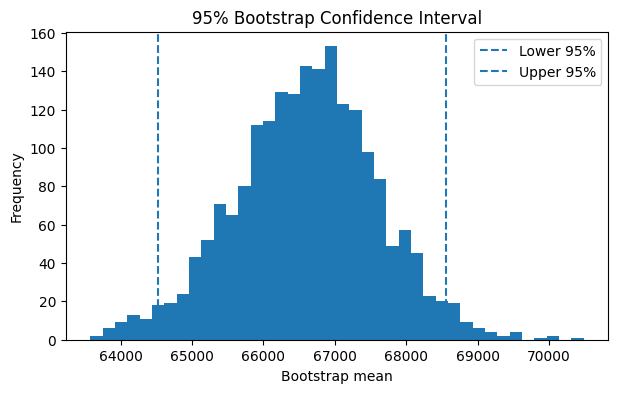

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(bootstrap_means, bins=40)
plt.axvline(lower, linestyle="--", label="Lower 95%")
plt.axvline(upper, linestyle="--", label="Upper 95%")
plt.xlabel("Bootstrap mean")
plt.ylabel("Frequency")
plt.title("95% Bootstrap Confidence Interval")
plt.legend()
plt.show()


## 8. Normal Distribution

Distribusi normal berbentuk seperti lonceng dan simetris.

Konsep penting:
- **standardization** mengurangi mean lalu membagi dengan standard deviation;
- **z-score** menunjukkan posisi suatu nilai relatif terhadap mean dalam satuan standard deviation;
- **standard normal distribution** memiliki mean 0 dan standard deviation 1.

Tidak semua data mentah harus berdistribusi normal. Dalam statistik, distribusi normal banyak digunakan untuk memodelkan error dan sampling distribution tertentu.


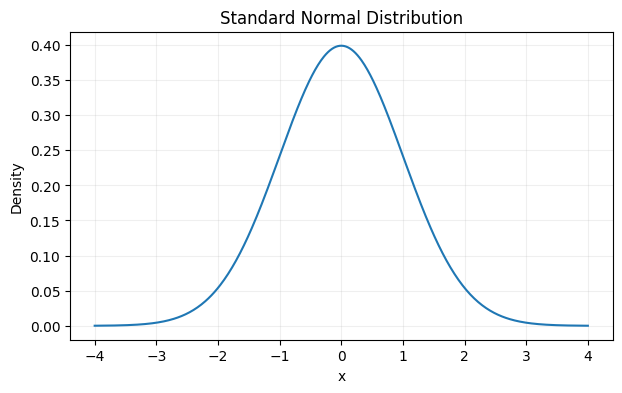

In [ ]:
# Membuat contoh normal distribution
x = np.linspace(-4, 4, 500)
normal_pdf = stats.norm.pdf(x)

plt.figure(figsize=(7, 4))
plt.plot(x, normal_pdf)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Standard Normal Distribution")
plt.grid(alpha=0.2)
plt.show()


In [ ]:
# Standardisasi data income
z_scores = stats.zscore(sample_income)

print(f"Mean z-score : {z_scores.mean():.3f}")
print(f"Std z-score  : {z_scores.std(ddof=1):.3f}")


Mean z-score : 0.000
Std z-score  : 1.001


## 9. QQ-Plot

**QQ-plot (Quantile-Quantile plot)** membandingkan quantile data dengan quantile distribusi teoritis, biasanya distribusi normal.

Jika titik-titik mengikuti garis referensi dengan cukup baik, data dapat dikatakan memiliki kemiripan dengan distribusi normal pada tingkat tertentu. Penyimpangan yang besar dari garis menunjukkan adanya perbedaan dari distribusi teoritis.


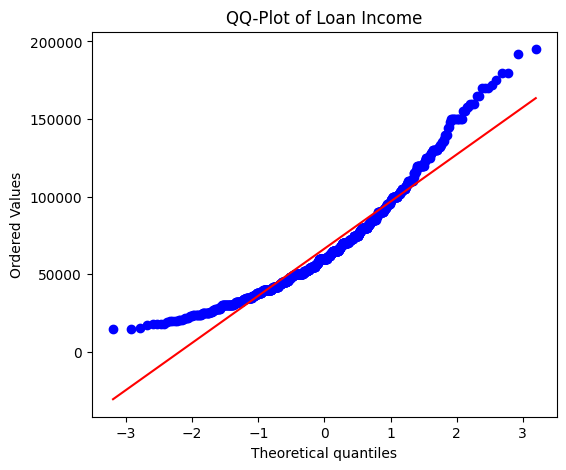

In [ ]:
plt.figure(figsize=(6, 5))
stats.probplot(sample_income, dist="norm", plot=plt)
plt.title("QQ-Plot of Loan Income")
plt.show()


## 10. Long-Tailed Distributions

Distribusi **long-tailed** memiliki ekor yang relatif panjang. Artinya, terdapat sebagian kecil observasi yang mempunyai nilai jauh dari pusat distribusi.

Data dunia nyata sering tidak mengikuti distribusi normal sempurna. Karena itu, mean dan standard deviation perlu digunakan dengan mempertimbangkan bentuk distribusi datanya.


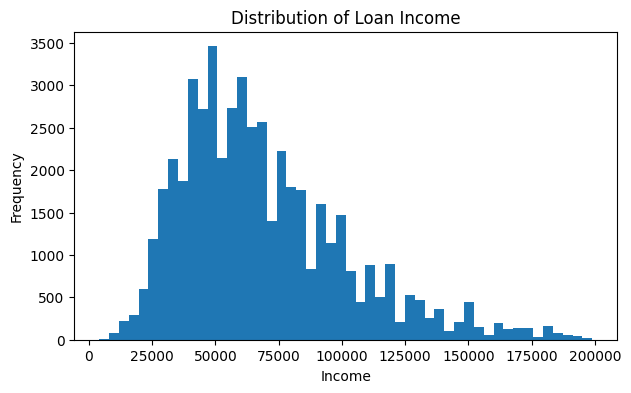

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(loans_income, bins=50)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Distribution of Loan Income")
plt.show()


## 11. Student's t-Distribution

**Student's t-distribution** mirip dengan distribusi normal tetapi memiliki ekor yang lebih tebal.

Distribusi ini dipengaruhi oleh **degrees of freedom**. Ketika degrees of freedom semakin besar, bentuk t-distribution semakin mendekati normal distribution.


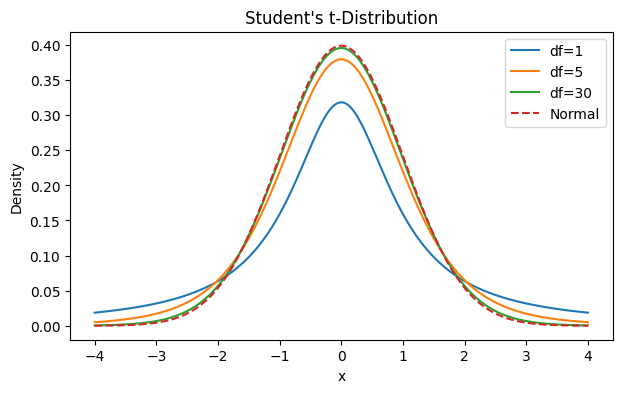

In [ ]:
x = np.linspace(-4, 4, 500)

plt.figure(figsize=(7, 4))
for df in [1, 5, 30]:
    plt.plot(x, stats.t.pdf(x, df), label=f"df={df}")

plt.plot(x, stats.norm.pdf(x), linestyle="--", label="Normal")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Student's t-Distribution")
plt.legend()
plt.show()


## 12. Binomial Distribution

**Binomial distribution** digunakan untuk memodelkan jumlah keberhasilan dari sejumlah percobaan yang:
- memiliki jumlah percobaan tetap;
- setiap percobaan mempunyai dua hasil;
- peluang keberhasilan dianggap sama;
- percobaan saling independen.

Parameter utamanya adalah `n` dan `p`.


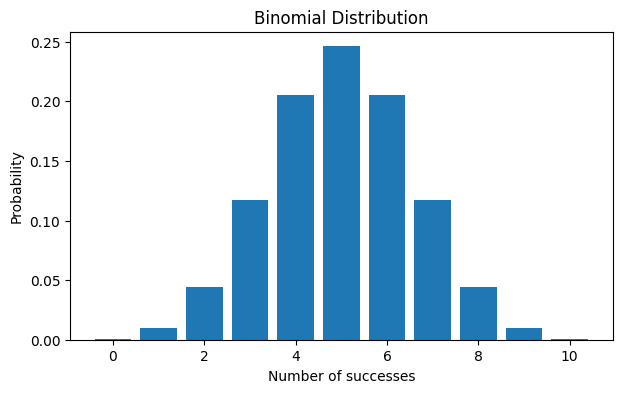

In [ ]:
n = 10
p = 0.5
x = np.arange(0, n + 1)

pmf = stats.binom.pmf(x, n, p)

plt.figure(figsize=(7, 4))
plt.bar(x, pmf)
plt.xlabel("Number of successes")
plt.ylabel("Probability")
plt.title("Binomial Distribution")
plt.show()


## 13. Chi-Square Distribution

**Chi-square distribution** sering digunakan dalam pengujian statistik dan berkaitan dengan jumlah kuadrat variabel normal standar.

Bentuk distribusinya bergantung pada degrees of freedom dan hanya mempunyai nilai non-negatif.


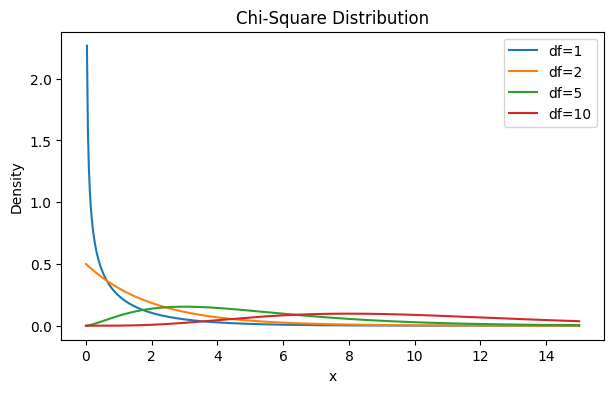

In [ ]:
x = np.linspace(0, 15, 500)

plt.figure(figsize=(7, 4))
for df in [1, 2, 5, 10]:
    plt.plot(x, stats.chi2.pdf(x, df), label=f"df={df}")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Chi-Square Distribution")
plt.legend()
plt.show()


## 14. F-Distribution

**F-distribution** digunakan dalam beberapa metode statistik, termasuk perbandingan varians dan analisis varians.

Bentuknya dipengaruhi oleh dua degrees of freedom.


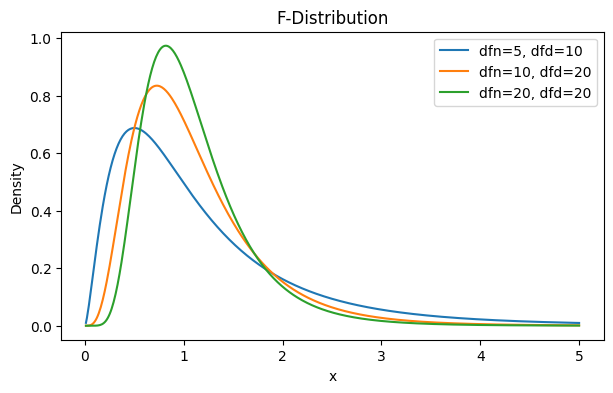

In [ ]:
x = np.linspace(0.01, 5, 500)

plt.figure(figsize=(7, 4))
for dfn, dfd in [(5, 10), (10, 20), (20, 20)]:
    plt.plot(
        x,
        stats.f.pdf(x, dfn, dfd),
        label=f"dfn={dfn}, dfd={dfd}"
    )

plt.xlabel("x")
plt.ylabel("Density")
plt.title("F-Distribution")
plt.legend()
plt.show()


## 15. Poisson Distribution

**Poisson distribution** digunakan untuk memodelkan jumlah kejadian dalam suatu interval ketika kejadian dihitung berdasarkan rata-rata tingkat kejadian tertentu.

Parameter utamanya adalah `lambda (λ)`, yaitu rata-rata jumlah kejadian pada interval tersebut.


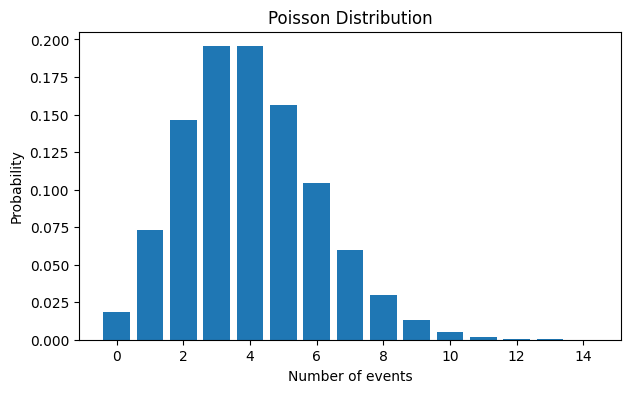

In [ ]:
lam = 4
x = np.arange(0, 15)

pmf = stats.poisson.pmf(x, lam)

plt.figure(figsize=(7, 4))
plt.bar(x, pmf)
plt.xlabel("Number of events")
plt.ylabel("Probability")
plt.title("Poisson Distribution")
plt.show()


## 16. Exponential Distribution

**Exponential distribution** sering digunakan untuk memodelkan waktu tunggu sampai suatu kejadian terjadi.

Distribusi ini berhubungan dengan Poisson process. Jika Poisson digunakan untuk menghitung jumlah kejadian dalam interval, exponential dapat digunakan untuk memodelkan waktu antar-kejadian.


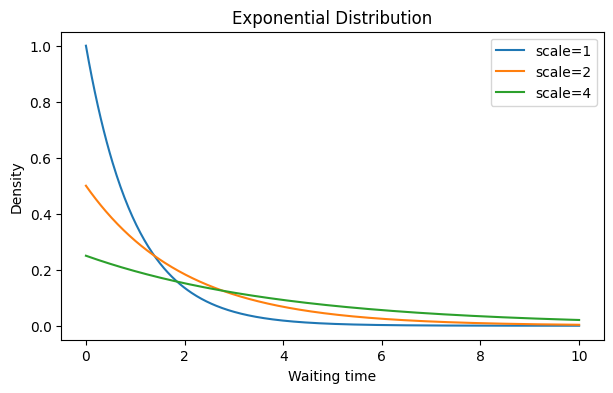

In [ ]:
x = np.linspace(0, 10, 500)

plt.figure(figsize=(7, 4))
for scale in [1, 2, 4]:
    plt.plot(
        x,
        stats.expon.pdf(x, scale=scale),
        label=f"scale={scale}"
    )

plt.xlabel("Waiting time")
plt.ylabel("Density")
plt.title("Exponential Distribution")
plt.legend()
plt.show()


## 17. Weibull Distribution

**Weibull distribution** merupakan distribusi kontinu yang banyak digunakan untuk memodelkan lifetime, reliability, dan waktu sampai suatu kejadian.

Bentuk distribusinya dapat berubah sesuai parameter shape.


/usr/local/lib/python3.13/dist-packages/scipy/stats/_continuous_distns.py:2750: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


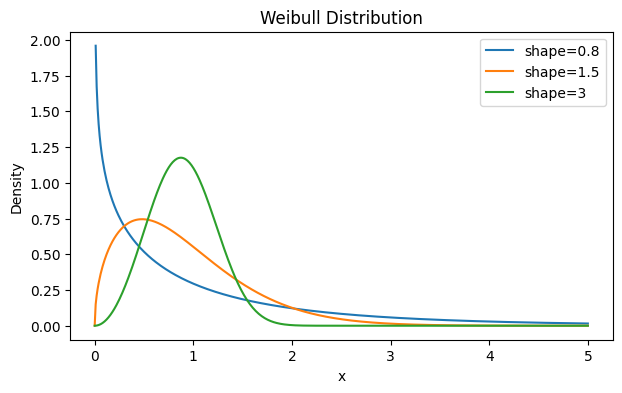

In [ ]:
x = np.linspace(0, 5, 500)

plt.figure(figsize=(7, 4))
for shape in [0.8, 1.5, 3]:
    plt.plot(
        x,
        stats.weibull_min.pdf(x, shape),
        label=f"shape={shape}"
    )

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Weibull Distribution")
plt.legend()
plt.show()


# Kesimpulan Bab 2

Bab 2 membahas bagaimana data dan proses sampling memengaruhi hasil analisis statistik.

Hal utama yang dipelajari:
1. Population dan sample memiliki peran berbeda.
2. Sample yang besar belum tentu bebas dari bias.
3. Selection bias dapat muncul dari proses pemilihan data.
4. Regression to the mean menjelaskan kecenderungan nilai ekstrem bergerak mendekati rata-rata pada pengukuran berikutnya.
5. Sampling distribution menjelaskan distribusi statistik dari banyak sample.
6. Central Limit Theorem membantu menjelaskan mengapa sample mean cenderung mendekati distribusi normal.
7. Standard error menggambarkan variabilitas sample statistic.
8. Bootstrap dapat digunakan untuk memperkirakan variabilitas dan confidence interval.
9. Distribusi normal, t, binomial, chi-square, F, Poisson, exponential, dan Weibull memiliki karakteristik dan penggunaan yang berbeda.

**Intinya:** sebelum menarik kesimpulan dari data, kita perlu memahami bagaimana data dikumpulkan, bagaimana sample dibentuk, dan bagaimana ketidakpastian statistik muncul.
